In [1]:

# imports
import os
import sys
import types
import json
import base64

# figure size/format
fig_width = 7
fig_height = 5
fig_format = 'retina'
fig_dpi = 96
interactivity = ''
is_shiny = False
is_dashboard = False
plotly_connected = True

# matplotlib defaults / format
try:
  import matplotlib.pyplot as plt
  plt.rcParams['figure.figsize'] = (fig_width, fig_height)
  plt.rcParams['figure.dpi'] = fig_dpi
  plt.rcParams['savefig.dpi'] = "figure"

  # IPython 7.14 deprecated set_matplotlib_formats from IPython
  try:
    from matplotlib_inline.backend_inline import set_matplotlib_formats
  except ImportError:
    # Fall back to deprecated location for older IPython versions
    from IPython.display import set_matplotlib_formats
    
  set_matplotlib_formats(fig_format)
except Exception:
  pass

# plotly use connected mode
try:
  import plotly.io as pio
  if plotly_connected:
    pio.renderers.default = "notebook_connected"
  else:
    pio.renderers.default = "notebook"
  for template in pio.templates.keys():
    pio.templates[template].layout.margin = dict(t=30,r=0,b=0,l=0)
except Exception:
  pass

# disable itables paging for dashboards
if is_dashboard:
  try:
    from itables import options
    options.dom = 'fiBrtlp'
    options.maxBytes = 1024 * 1024
    options.language = dict(info = "Showing _TOTAL_ entries")
    options.classes = "display nowrap compact"
    options.paging = False
    options.searching = True
    options.ordering = True
    options.info = True
    options.lengthChange = False
    options.autoWidth = False
    options.responsive = True
    options.keys = True
    options.buttons = []
  except Exception:
    pass
  
  try:
    import altair as alt
    # By default, dashboards will have container sized
    # vega visualizations which allows them to flow reasonably
    theme_sentinel = '_quarto-dashboard-internal'
    def make_theme(name):
        nonTheme = alt.themes._plugins[name]    
        def patch_theme(*args, **kwargs):
            existingTheme = nonTheme()
            if 'height' not in existingTheme:
              existingTheme['height'] = 'container'
            if 'width' not in existingTheme:
              existingTheme['width'] = 'container'

            if 'config' not in existingTheme:
              existingTheme['config'] = dict()
            
            # Configure the default font sizes
            title_font_size = 15
            header_font_size = 13
            axis_font_size = 12
            legend_font_size = 12
            mark_font_size = 12
            tooltip = False

            config = existingTheme['config']

            # The Axis
            if 'axis' not in config:
              config['axis'] = dict()
            axis = config['axis']
            if 'labelFontSize' not in axis:
              axis['labelFontSize'] = axis_font_size
            if 'titleFontSize' not in axis:
              axis['titleFontSize'] = axis_font_size  

            # The legend
            if 'legend' not in config:
              config['legend'] = dict()
            legend = config['legend']
            if 'labelFontSize' not in legend:
              legend['labelFontSize'] = legend_font_size
            if 'titleFontSize' not in legend:
              legend['titleFontSize'] = legend_font_size  

            # The header
            if 'header' not in config:
              config['header'] = dict()
            header = config['header']
            if 'labelFontSize' not in header:
              header['labelFontSize'] = header_font_size
            if 'titleFontSize' not in header:
              header['titleFontSize'] = header_font_size    

            # Title
            if 'title' not in config:
              config['title'] = dict()
            title = config['title']
            if 'fontSize' not in title:
              title['fontSize'] = title_font_size

            # Marks
            if 'mark' not in config:
              config['mark'] = dict()
            mark = config['mark']
            if 'fontSize' not in mark:
              mark['fontSize'] = mark_font_size

            # Mark tooltips
            if tooltip and 'tooltip' not in mark:
              mark['tooltip'] = dict(content="encoding")

            return existingTheme
            
        return patch_theme

    # We can only do this once per session
    if theme_sentinel not in alt.themes.names():
      for name in alt.themes.names():
        alt.themes.register(name, make_theme(name))
      
      # register a sentinel theme so we only do this once
      alt.themes.register(theme_sentinel, make_theme('default'))
      alt.themes.enable('default')

  except Exception:
    pass

# enable pandas latex repr when targeting pdfs
try:
  import pandas as pd
  if fig_format == 'pdf':
    pd.set_option('display.latex.repr', True)
except Exception:
  pass

# interactivity
if interactivity:
  from IPython.core.interactiveshell import InteractiveShell
  InteractiveShell.ast_node_interactivity = interactivity

# NOTE: the kernel_deps code is repeated in the cleanup.py file
# (we can't easily share this code b/c of the way it is run).
# If you edit this code also edit the same code in cleanup.py!

# output kernel dependencies
kernel_deps = dict()
for module in list(sys.modules.values()):
  # Some modules play games with sys.modules (e.g. email/__init__.py
  # in the standard library), and occasionally this can cause strange
  # failures in getattr.  Just ignore anything that's not an ordinary
  # module.
  if not isinstance(module, types.ModuleType):
    continue
  path = getattr(module, "__file__", None)
  if not path:
    continue
  if path.endswith(".pyc") or path.endswith(".pyo"):
    path = path[:-1]
  if not os.path.exists(path):
    continue
  kernel_deps[path] = os.stat(path).st_mtime
print(json.dumps(kernel_deps))

# set run_path if requested
run_path = 'L1VzZXJzL2dvbnphbG92aWRhbC9Eb2N1bWVudHMvR2l0SHViL1B5dGhvbl9mb3JfU3ludGhldGljX0Jpb2xvZ3kvY2hhcHRlcnM='
if run_path:
  # hex-decode the path
  run_path = base64.b64decode(run_path.encode("utf-8")).decode("utf-8")
  os.chdir(run_path)

# reset state
%reset

# shiny
# Checking for shiny by using False directly because we're after the %reset. We don't want
# to set a variable that stays in global scope.
if False:
  try:
    import htmltools as _htmltools
    import ast as _ast

    _htmltools.html_dependency_render_mode = "json"

    # This decorator will be added to all function definitions
    def _display_if_has_repr_html(x):
      try:
        # IPython 7.14 preferred import
        from IPython.display import display, HTML
      except:
        from IPython.core.display import display, HTML

      if hasattr(x, '_repr_html_'):
        display(HTML(x._repr_html_()))
      return x

    # ideally we would undo the call to ast_transformers.append
    # at the end of this block whenver an error occurs, we do 
    # this for now as it will only be a problem if the user 
    # switches from shiny to not-shiny mode (and even then likely
    # won't matter)
    import builtins
    builtins._display_if_has_repr_html = _display_if_has_repr_html

    class _FunctionDefReprHtml(_ast.NodeTransformer):
      def visit_FunctionDef(self, node):
        node.decorator_list.insert(
          0,
          _ast.Name(id="_display_if_has_repr_html", ctx=_ast.Load())
        )
        return node

      def visit_AsyncFunctionDef(self, node):
        node.decorator_list.insert(
          0,
          _ast.Name(id="_display_if_has_repr_html", ctx=_ast.Load())
        )
        return node

    ip = get_ipython()
    ip.ast_transformers.append(_FunctionDefReprHtml())

  except:
    pass

def ojs_define(**kwargs):
  import json
  try:
    # IPython 7.14 preferred import
    from IPython.display import display, HTML
  except:
    from IPython.core.display import display, HTML

  # do some minor magic for convenience when handling pandas
  # dataframes
  def convert(v):
    try:
      import pandas as pd
    except ModuleNotFoundError: # don't do the magic when pandas is not available
      return v
    if type(v) == pd.Series:
      v = pd.DataFrame(v)
    if type(v) == pd.DataFrame:
      j = json.loads(v.T.to_json(orient='split'))
      return dict((k,v) for (k,v) in zip(j["index"], j["data"]))
    else:
      return v

  v = dict(contents=list(dict(name=key, value=convert(value)) for (key, value) in kwargs.items()))
  display(HTML('<script type="ojs-define">' + json.dumps(v) + '</script>'), metadata=dict(ojs_define = True))
globals()["ojs_define"] = ojs_define
globals()["__spec__"] = None

{"/Users/gonzalovidal/opt/anaconda3/envs/psb/lib/python3.11/importlib/_bootstrap.py": 1749130019.08049, "/Users/gonzalovidal/opt/anaconda3/envs/psb/lib/python3.11/importlib/_bootstrap_external.py": 1749130019.092533, "/Users/gonzalovidal/opt/anaconda3/envs/psb/lib/python3.11/zipimport.py": 1749130014.228809, "/Users/gonzalovidal/opt/anaconda3/envs/psb/lib/python3.11/codecs.py": 1749130012.791808, "/Users/gonzalovidal/opt/anaconda3/envs/psb/lib/python3.11/encodings/aliases.py": 1749130016.218093, "/Users/gonzalovidal/opt/anaconda3/envs/psb/lib/python3.11/encodings/__init__.py": 1749130016.206209, "/Users/gonzalovidal/opt/anaconda3/envs/psb/lib/python3.11/encodings/utf_8.py": 1749130017.621478, "/Users/gonzalovidal/opt/anaconda3/envs/psb/lib/python3.11/abc.py": 1749130012.596308, "/Users/gonzalovidal/opt/anaconda3/envs/psb/lib/python3.11/io.py": 1749130013.2025, "/Users/gonzalovidal/opt/anaconda3/envs/psb/lib/python3.11/stat.py": 1749130013.847848, "/Users/gonzalovidal/opt/anaconda3/envs

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

beta = 4.0
gamma = 0.5

time = np.linspace(0, 12, 121)
protein = beta / gamma * (1 - np.exp(-gamma * time))

analytic_df = pd.DataFrame(
    {
        "time_h": time,
        "species": "protein",
        "value": protein,
        "model": "analytic",
        "condition": "baseline",
    }
)

analytic_df.head()

,time_h,species,value,model,condition
0,0.0,protein,0.000000,analytic,baseline
1,0.1,protein,0.390165,analytic,baseline
2,0.2,protein,0.761301,analytic,baseline
3,0.3,protein,1.114336,analytic,baseline
4,0.4,protein,1.450154,analytic,baseline


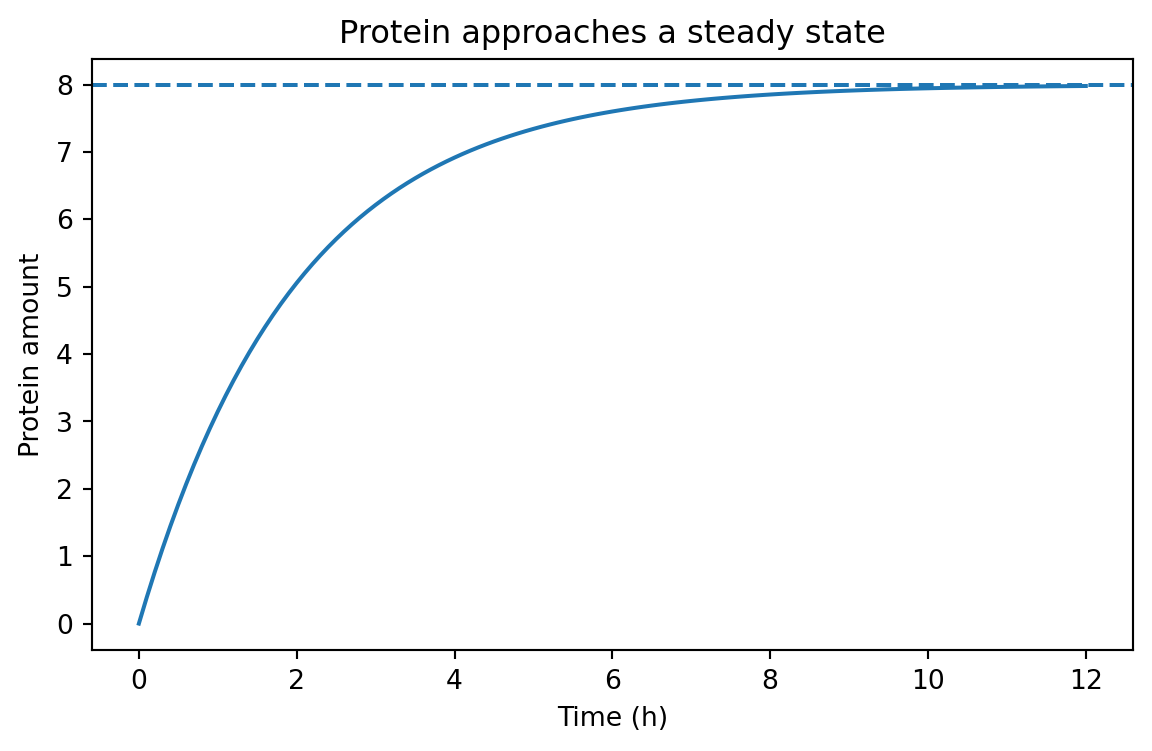

In [3]:
plt.figure(figsize=(7, 4))
plt.plot(analytic_df["time_h"], analytic_df["value"])
plt.axhline(beta / gamma, linestyle="--")
plt.xlabel("Time (h)")
plt.ylabel("Protein amount")
plt.title("Protein approaches a steady state")
plt.show()

In [4]:
def simulate_protein(beta, gamma, t_end=12, dt=0.1, p0=0.0, condition="baseline"):
    times = np.arange(0, t_end + dt, dt)
    p = p0
    records = []

    for t in times:
        records.append(
            {
                "time_h": t,
                "species": "protein",
                "value": p,
                "condition": condition,
                "model": "euler",
            }
        )
        dp_dt = beta - gamma * p
        p = p + dt * dp_dt

    return pd.DataFrame(records)

euler_df = simulate_protein(beta=4.0, gamma=0.5)
euler_df.head()

,time_h,species,value,condition,model
0,0.0,protein,0.00000,baseline,euler
1,0.1,protein,0.40000,baseline,euler
2,0.2,protein,0.78000,baseline,euler
3,0.3,protein,1.14100,baseline,euler
4,0.4,protein,1.48395,baseline,euler


In [5]:
comparison_df = pd.concat([analytic_df, euler_df], ignore_index=True)
comparison_df.head()

,time_h,species,value,model,condition
0,0.0,protein,0.000000,analytic,baseline
1,0.1,protein,0.390165,analytic,baseline
2,0.2,protein,0.761301,analytic,baseline
3,0.3,protein,1.114336,analytic,baseline
4,0.4,protein,1.450154,analytic,baseline


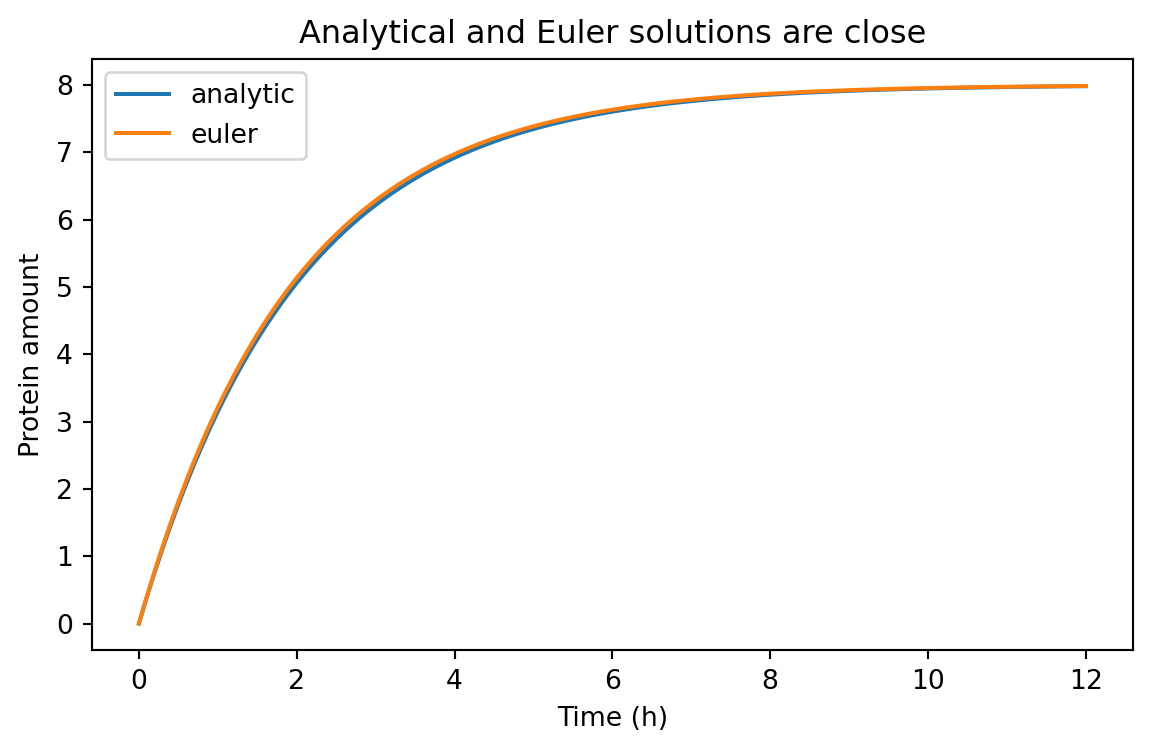

In [6]:
plt.figure(figsize=(7, 4))

for model_name, subset in comparison_df.groupby("model"):
    plt.plot(subset["time_h"], subset["value"], label=model_name)

plt.xlabel("Time (h)")
plt.ylabel("Protein amount")
plt.title("Analytical and Euler solutions are close")
plt.legend()
plt.show()

In [7]:
rate_sweep = pd.concat(
    [
        simulate_protein(beta=4.0, gamma=0.2, condition="gamma=0.2"),
        simulate_protein(beta=4.0, gamma=0.5, condition="gamma=0.5"),
        simulate_protein(beta=4.0, gamma=1.0, condition="gamma=1.0"),
    ],
    ignore_index=True,
)

rate_sweep.head()

,time_h,species,value,condition,model
0,0.0,protein,0.000000,gamma=0.2,euler
1,0.1,protein,0.400000,gamma=0.2,euler
2,0.2,protein,0.792000,gamma=0.2,euler
3,0.3,protein,1.176160,gamma=0.2,euler
4,0.4,protein,1.552637,gamma=0.2,euler


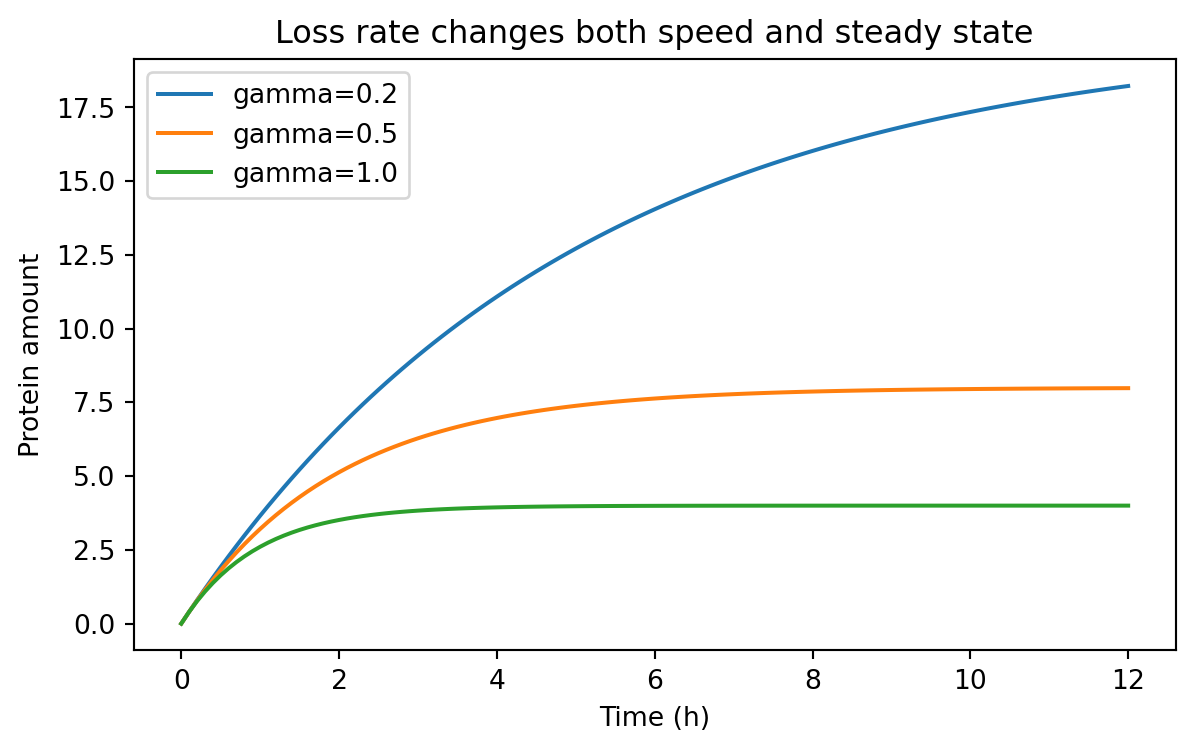

In [8]:
plt.figure(figsize=(7, 4))
for condition, subset in rate_sweep.groupby("condition"):
    plt.plot(subset["time_h"], subset["value"], label=condition)

plt.xlabel("Time (h)")
plt.ylabel("Protein amount")
plt.title("Loss rate changes both speed and steady state")
plt.legend()
plt.show()

In [9]:
final_values = (
    rate_sweep.sort_values("time_h")
    .groupby(["condition", "species"], as_index=False)
    .tail(1)
    .loc[:, ["condition", "species", "value"]]
    .rename(columns={"value": "final_value"})
    .reset_index(drop=True)
)

final_values

,condition,species,final_value
0,gamma=1.0,protein,3.999987
1,gamma=0.5,protein,7.983021
2,gamma=0.2,protein,18.229243


In [10]:
def simulate_mrna_protein(
    alpha,
    delta_m,
    k_tl,
    delta_p,
    t_end=12,
    dt=0.05,
    m0=0.0,
    p0=0.0,
    condition="baseline",
):
    times = np.arange(0, t_end + dt, dt)
    m = m0
    p = p0
    records = []

    for t in times:
        records.append({"time_h": t, "species": "mRNA", "value": m, "condition": condition})
        records.append({"time_h": t, "species": "protein", "value": p, "condition": condition})

        dm_dt = alpha - delta_m * m
        dp_dt = k_tl * m - delta_p * p

        m = m + dt * dm_dt
        p = p + dt * dp_dt

    return pd.DataFrame(records)

two_stage_df = simulate_mrna_protein(
    alpha=6.0,
    delta_m=2.0,
    k_tl=3.0,
    delta_p=0.4,
)

two_stage_df.head()

,time_h,species,value,condition
0,0.00,mRNA,0.00,baseline
1,0.00,protein,0.00,baseline
2,0.05,mRNA,0.30,baseline
3,0.05,protein,0.00,baseline
4,0.10,mRNA,0.57,baseline


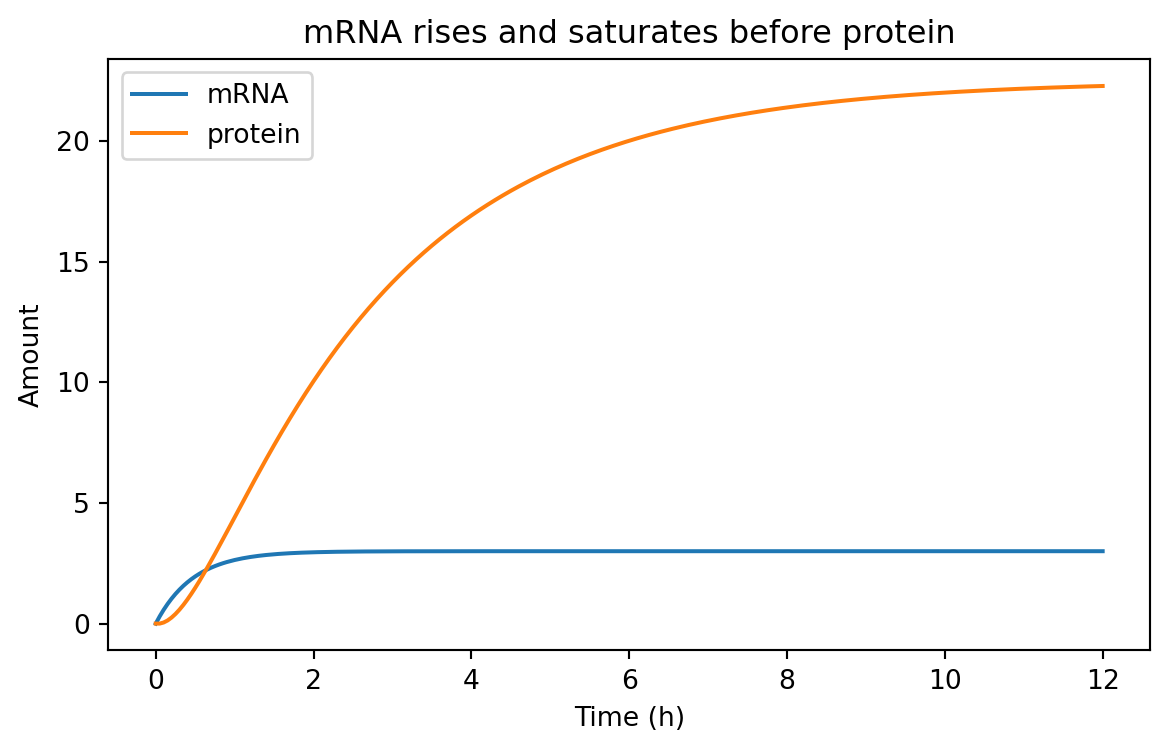

In [11]:
plt.figure(figsize=(7, 4))
for species, subset in two_stage_df.groupby("species"):
    plt.plot(subset["time_h"], subset["value"], label=species)

plt.xlabel("Time (h)")
plt.ylabel("Amount")
plt.title("mRNA rises and saturates before protein")
plt.legend()
plt.show()

In [12]:
promoter_sweep = pd.concat(
    [
        simulate_mrna_protein(2.5, 2.0, 3.0, 0.4, condition="weak promoter"),
        simulate_mrna_protein(6.0, 2.0, 3.0, 0.4, condition="medium promoter"),
        simulate_mrna_protein(10.0, 2.0, 3.0, 0.4, condition="strong promoter"),
    ],
    ignore_index=True,
)

protein_only = promoter_sweep[promoter_sweep["species"] == "protein"]
protein_only.head()

,time_h,species,value,condition
1,0.00,protein,0.000000,weak promoter
3,0.05,protein,0.000000,weak promoter
5,0.10,protein,0.018750,weak promoter
7,0.15,protein,0.054000,weak promoter
9,0.20,protein,0.103733,weak promoter


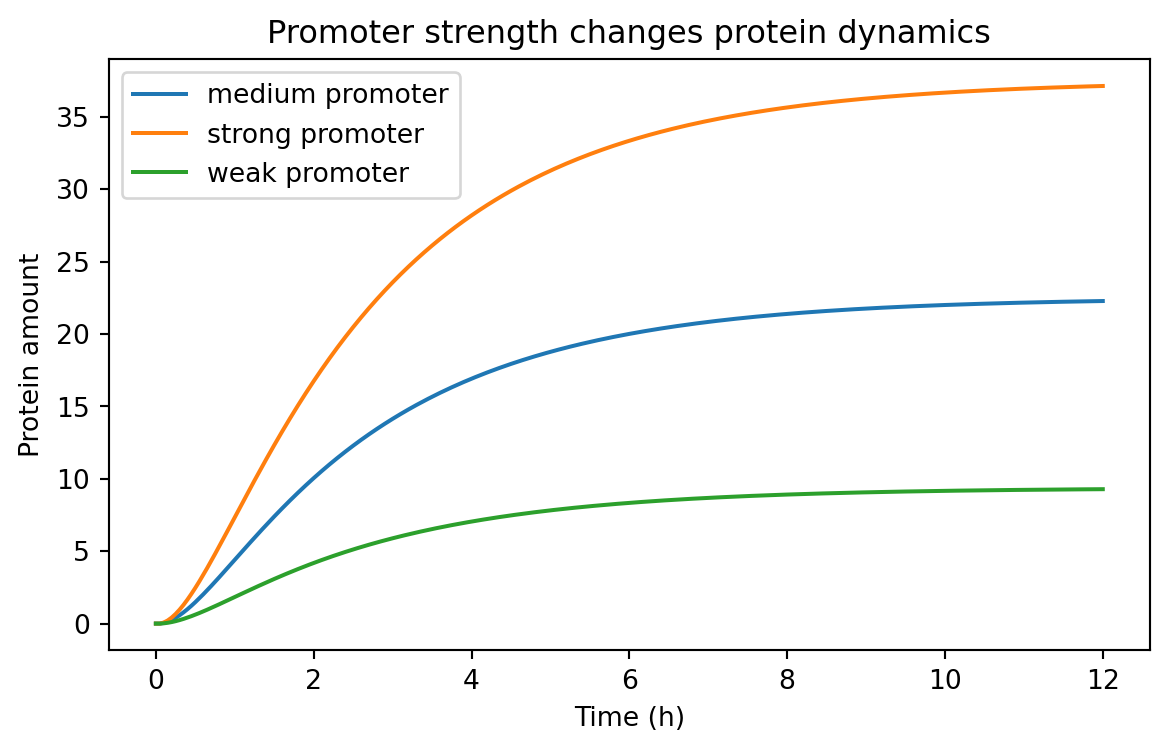

In [13]:
plt.figure(figsize=(7, 4))
for condition, subset in protein_only.groupby("condition"):
    plt.plot(subset["time_h"], subset["value"], label=condition)

plt.xlabel("Time (h)")
plt.ylabel("Protein amount")
plt.title("Promoter strength changes protein dynamics")
plt.legend()
plt.show()

In [14]:
def hill_activation(x, K, n):
    x = np.asarray(x, dtype=float)
    return (x**n) / (K**n + x**n)


def hill_repression(x, K, n):
    x = np.asarray(x, dtype=float)
    return (K**n) / (K**n + x**n)

inducer = np.linspace(0, 100, 201)
activation = hill_activation(inducer, K=20, n=2)
repression = hill_repression(inducer, K=20, n=2)

hill_df = pd.DataFrame(
    {
        "inducer_uM": np.concatenate([inducer, inducer]),
        "response": np.concatenate([activation, repression]),
        "relationship": ["activation"] * len(inducer) + ["repression"] * len(inducer),
    }
)

hill_df.head()

,inducer_uM,response,relationship
0,0.0,0.000000,activation
1,0.5,0.000625,activation
2,1.0,0.002494,activation
3,1.5,0.005594,activation
4,2.0,0.009901,activation


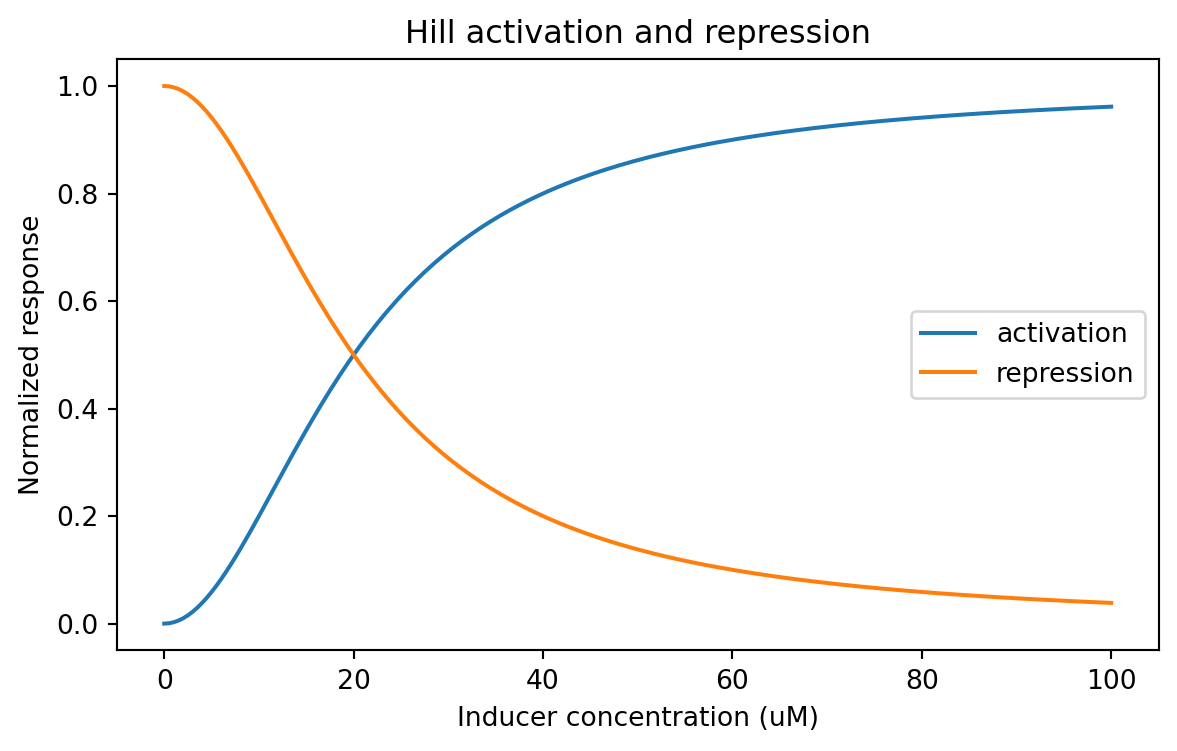

In [15]:
plt.figure(figsize=(7, 4))
for relationship, subset in hill_df.groupby("relationship"):
    plt.plot(subset["inducer_uM"], subset["response"], label=relationship)

plt.xlabel("Inducer concentration (uM)")
plt.ylabel("Normalized response")
plt.title("Hill activation and repression")
plt.legend()
plt.show()

In [16]:
alpha_max = 12.0
gamma = 0.6
inducer_values = np.linspace(0, 100, 41)

response_records = []
for x in inducer_values:
    beta_x = alpha_max * hill_activation(x, K=20, n=2)
    p_ss = beta_x / gamma
    response_records.append(
        {
            "inducer_uM": x,
            "steady_state_protein": p_ss,
            "K": 20,
            "hill_n": 2,
        }
    )

dose_response_df = pd.DataFrame(response_records)
dose_response_df.head()

,inducer_uM,steady_state_protein,K,hill_n
0,0.0,0.000000,20,2
1,2.5,0.307692,20,2
2,5.0,1.176471,20,2
3,7.5,2.465753,20,2
4,10.0,4.000000,20,2


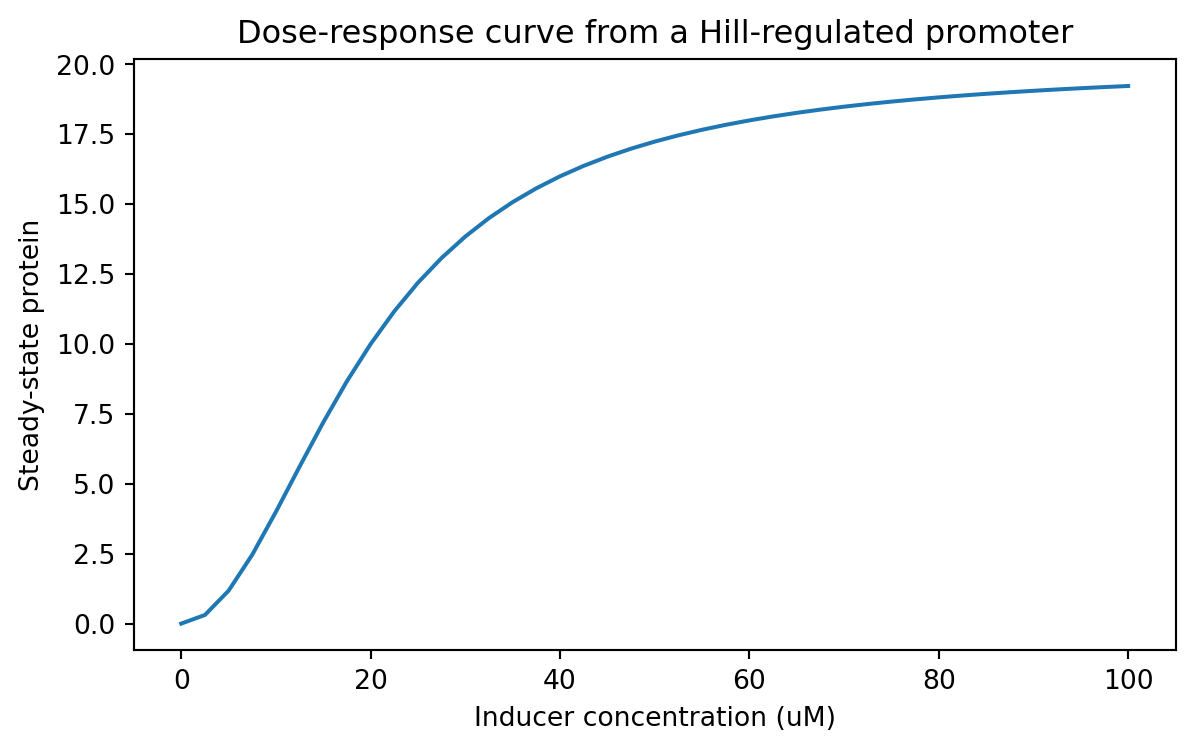

In [17]:
plt.figure(figsize=(7, 4))
plt.plot(dose_response_df["inducer_uM"], dose_response_df["steady_state_protein"])
plt.xlabel("Inducer concentration (uM)")
plt.ylabel("Steady-state protein")
plt.title("Dose-response curve from a Hill-regulated promoter")
plt.show()

In [18]:
parameter_sweep_records = []

for n_value in [1, 2, 4]:
    for x in inducer_values:
        beta_x = alpha_max * hill_activation(x, K=20, n=n_value)
        p_ss = beta_x / gamma
        parameter_sweep_records.append(
            {
                "inducer_uM": x,
                "steady_state_protein": p_ss,
                "hill_n": n_value,
                "K": 20,
                "parameter": "hill_n",
            }
        )

parameter_sweep_df = pd.DataFrame(parameter_sweep_records)
parameter_sweep_df.head()

,inducer_uM,steady_state_protein,hill_n,K,parameter
0,0.0,0.000000,1,20,hill_n
1,2.5,2.222222,1,20,hill_n
2,5.0,4.000000,1,20,hill_n
3,7.5,5.454545,1,20,hill_n
4,10.0,6.666667,1,20,hill_n


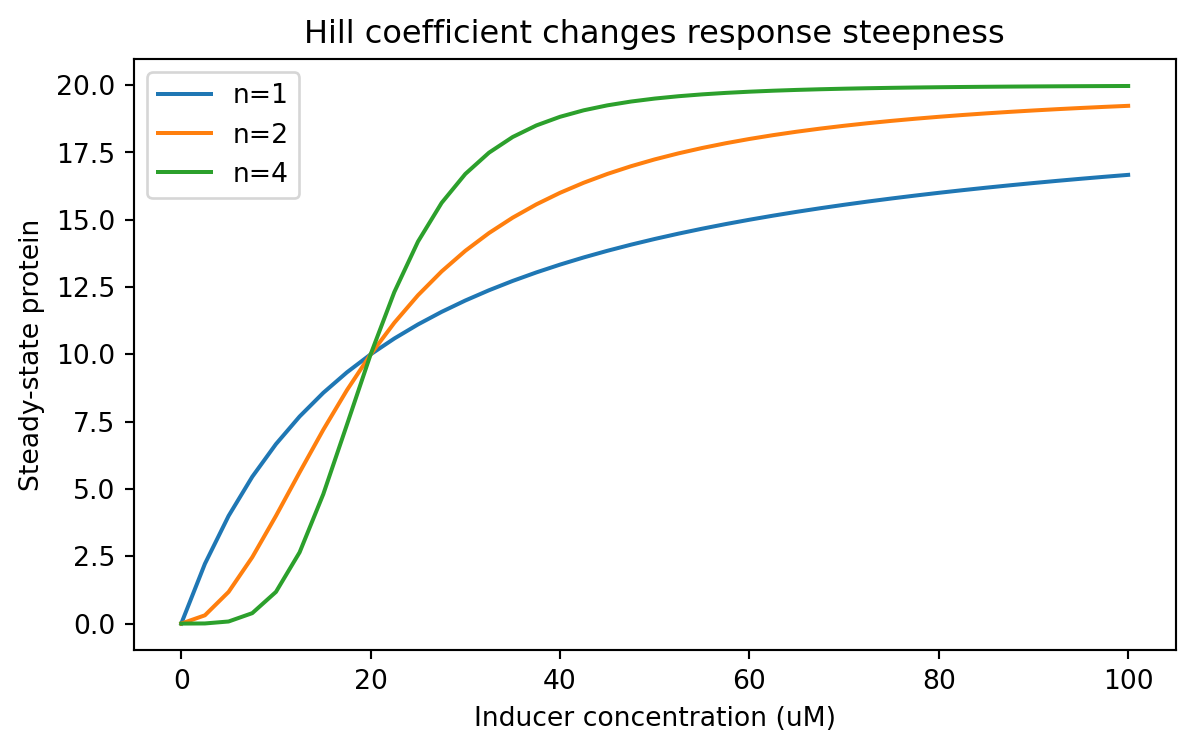

In [19]:
plt.figure(figsize=(7, 4))
for hill_n, subset in parameter_sweep_df.groupby("hill_n"):
    plt.plot(subset["inducer_uM"], subset["steady_state_protein"], label=f"n={hill_n}")

plt.xlabel("Inducer concentration (uM)")
plt.ylabel("Steady-state protein")
plt.title("Hill coefficient changes response steepness")
plt.legend()
plt.show()

In [20]:
half_max_summary = []
max_output = parameter_sweep_df["steady_state_protein"].max()

for hill_n, subset in parameter_sweep_df.groupby("hill_n"):
    threshold = subset["steady_state_protein"].max() / 2
    above = subset[subset["steady_state_protein"] >= threshold]
    first_crossing = above["inducer_uM"].min()
    half_max_summary.append({"hill_n": hill_n, "half_max_inducer_uM": first_crossing})

half_max_df = pd.DataFrame(half_max_summary)
half_max_df

,hill_n,half_max_inducer_uM
0,1,15.0
1,2,20.0
2,4,20.0


In [21]:
def simulate_induced_protein(inducer_uM, alpha_max, K, n, gamma, t_end=12, dt=0.1, condition=None):
    if condition is None:
        condition = f"inducer={inducer_uM}"

    beta = alpha_max * hill_activation(inducer_uM, K=K, n=n)
    return simulate_protein(beta=beta, gamma=gamma, t_end=t_end, dt=dt, condition=condition)

induction_timecourse_df = pd.concat(
    [
        simulate_induced_protein(0, 12.0, 20, 2, 0.6, condition="0 uM"),
        simulate_induced_protein(10, 12.0, 20, 2, 0.6, condition="10 uM"),
        simulate_induced_protein(30, 12.0, 20, 2, 0.6, condition="30 uM"),
        simulate_induced_protein(100, 12.0, 20, 2, 0.6, condition="100 uM"),
    ],
    ignore_index=True,
)

induction_timecourse_df.head()

,time_h,species,value,condition,model
0,0.0,protein,0.0,0 uM,euler
1,0.1,protein,0.0,0 uM,euler
2,0.2,protein,0.0,0 uM,euler
3,0.3,protein,0.0,0 uM,euler
4,0.4,protein,0.0,0 uM,euler


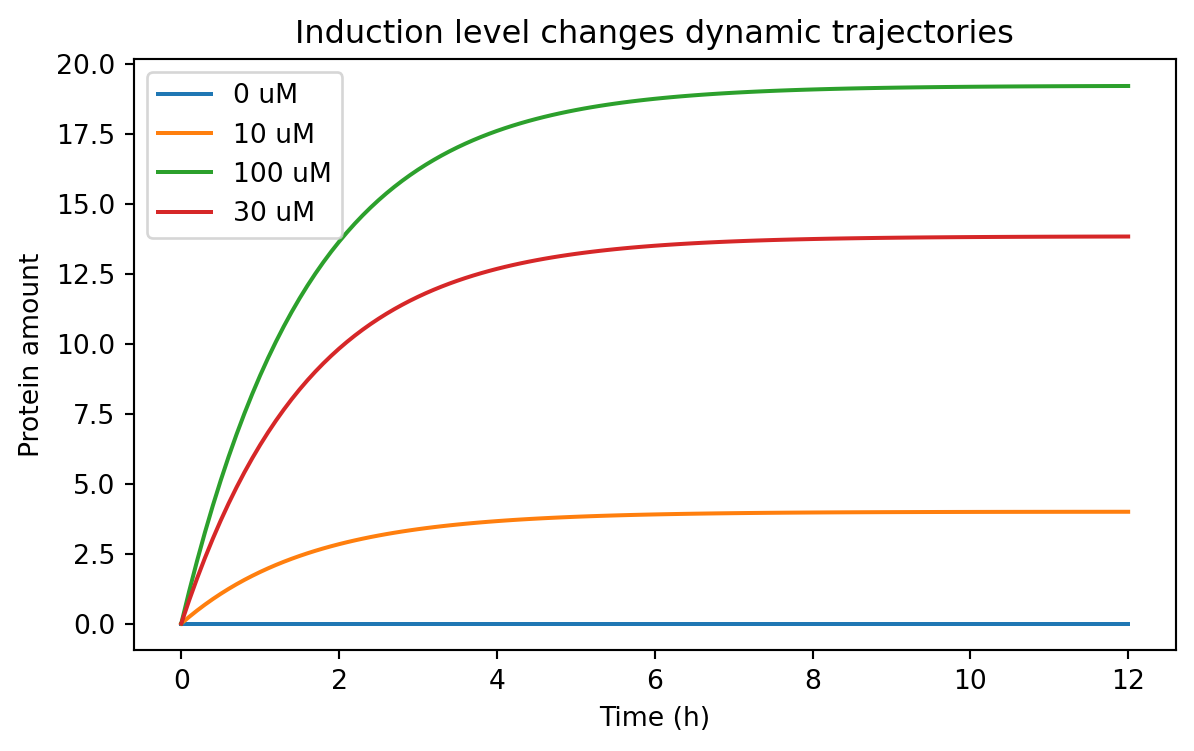

In [22]:
plt.figure(figsize=(7, 4))
for condition, subset in induction_timecourse_df.groupby("condition"):
    plt.plot(subset["time_h"], subset["value"], label=condition)

plt.xlabel("Time (h)")
plt.ylabel("Protein amount")
plt.title("Induction level changes dynamic trajectories")
plt.legend()
plt.show()